# MLP para reconocimientos de paisajes.

## Descripcion del negocio y del problema

Se necesita crear un modelo de aprendizaje que sea capaz de reconocer y diferencias distintos paisajes o espacios natuarales. Esto seria importante para modelos que necesitan de reconomiento de paisajes, por ejemplo un modelo que podria evaluar donde es ppsible encontrar cierto tipos de animales dependiendo del paisaje, etc.

## Seleccion y descripcion

A continuacion se describe el dataset utilizado para este proyecto :

*   Nombre : Intel Image Classification
*   Cantidad de imagenes : 25.000
*   Resolción : 150x150 pixeles
*   6 clases





### Caracteristicas principales

Las caracterisitcas principales de este dataset es que dentro vienen tres carpetas 'seg_pred' , 'seg_test' y 'seg_train'. Estos carpetas porque lo que se puede intuir tienen que ver con un conjunto de imganes para predecir, entrenar y hacer pruebas. La carpeta 'seg_pred' tiene un conjunto de imagenes desordenadas, la carpeta 'seg_test' tiene un conjutno de carpetas , las carpetas son :



*   buildings
*   forest
*   glacier
*   mountain
*   sea
*   street


Cada carpeta contiene imagenes correspondiente al paisaje del mismo nombre, osea la carpeta 'forest' que traducido al español es 'bosque', contiene solo fotos de bosques.




### Eleccion del dataset

Elegimos este dataset porque nos parece llamativo que un modelo pueda diferenciar disitntos paisajes, podria ayudar para poder generar imagenes y cosas por el estilo.

## Analisis exploratorio de las imagenes

### Distribución de las clases

El dataset esta distribuido en 6 clases, las cuales son las siguientes :

*   buildings
*   forest
*   glacier
*   mountain
*   sea
*   street

### Resolución y canales

Tiene 25.000 imagenes y cada imagen tiene una resolución de 150x150 pixeles, estas imageens estan distribuidas en disitntos archivos, especificamente en la carpeta train , hay 6 archivo con el nombre de las calses anteriormente descrito,

buildings : 437   
forest : 473  
glacier : 553  
mountain : 525  
sea : 510   
street : 501

Por lo que se logra apreciar, las capretas no tienen el mismo numero de archivos

### Variabilidad encontrada

Por que lo se encuentra en los archivos, se logra diferenciar que cada imagen corresponde a un paisaje distinto. especificamente cambian la distribucion de los colores.

building : predominan las estrucutras de lienas rectas o formas rectangulares

forest : predomina el color verde en distitnas tonalalidades, presenta figuras rectanguales deslgadas

glacier : predomina el color blanco, azul y celeste, las figuras presentan definiciones mas curvas que rectas.

mountain : predominan figuras traingulares

sea : predomina disitntas tonaldiad de azul, con la carencia de figuras presentes.

Street : espacios estrechos, aparecen personas y obejtos urbanos

# Preprocesamiento de datos

## Carga de los datos

Atravez de os verificaremos si es que esta el archivo o el dataset para poder usarlo

In [2]:
import os #importamos os para navegar a travez de los archivos

ruta_principal = "./dataset/Intel image Classification"

ruta_train = os.path.join(ruta_principal,"seg_train/seg_train")
ruta_test = os.path.join(ruta_principal,"seg_test/seg_test")


if os.path.exists(ruta_train) and os.path.exists(ruta_test):
    print("¡Éxito! Las carpetas de entrenamiento y prueba se han cargado correctamente.")
    
    #listdir para mostrar elementos de una carpeta
    clases = os.listdir(ruta_train)
    print(f"Clases encontradas: {clases}")
else:
    print("Error: No se encontraron las carpetas. Revisa que el nombre y la ubicación sean correctos.")


¡Éxito! Las carpetas de entrenamiento y prueba se han cargado correctamente.
Clases encontradas: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


Estas clases vendrian tambien siendo nuestras categorias, osea el modelo debera decirnos a que clase corresponde la imagen procesada

## Limpieza de los datos

Antes creamos una copia de los archivos para no alterar la fuente original

In [3]:
import os
import shutil

# Definimos las rutas
ruta_principal = './dataset'  # Cambia esto al nombre de tu carpeta original (ej. './intel')
ruta_copia = './copy'

# Verificamos si la carpeta original existe
if os.path.exists(ruta_principal):
    print("La carpeta original ha sido encontrada.")
    
    # Verificamos si la copia YA existe para no duplicar el trabajo
    if os.path.exists(ruta_copia):
        print(f"La carpeta '{ruta_copia}' ya existe. No es necesario hacer una nueva copia.")
    else:
        # Si no existe, hacemos la copia completa usando shutil
        print(f"Creando copia de seguridad en la carpeta '{ruta_copia}'... esto puede tomar unos segundos.")
        
        # shutil.copytree copia la carpeta principal y todo lo que tiene adentro
        shutil.copytree(ruta_principal, ruta_copia) 
        
        print("¡Copia de seguridad creada exitosamente!")
else:
    print(f"Error: No se encontró la carpeta original en la ruta: {ruta_principal}")

La carpeta original ha sido encontrada.
La carpeta './copy' ya existe. No es necesario hacer una nueva copia.


Reasignamos las variables de rutas , pero ahora con las copias

In [4]:
ruta_copia = "./copy/Intel image Classification"

ruta_train = os.path.join(ruta_copia,"seg_train/seg_train")
ruta_test = os.path.join(ruta_copia,"seg_test/seg_test")


Con la casilla anterior lo que hacemos es guardar en distintas variables las carpetas que corresponden a las rutas donde hay imagenes para testear y para entrenar

Pasamos a hacer una limpiza, verificamos si hay archivos con las extensones espereradas

In [5]:
# Definimos las extensiones que sí aceptamos

if os.path.exists(ruta_copia) :  #Verificamos de que la copia este creada
    extensiones_validas = ['.jpg', '.jpeg', '.png']
    imagenes_corruptas_o_basura = 0

    # Recorremos todas las carpetas y archivos dentro de seg_train
    for clase in os.listdir(ruta_train):
        ruta_clase = os.path.join(ruta_train, clase)
        
        # Nos aseguramos de que sea una carpeta (ignoramos si hay un archivo suelto ahí)
        if os.path.isdir(ruta_clase):
            for archivo in os.listdir(ruta_clase):
                ruta_archivo = os.path.join(ruta_clase, archivo)
                
                # Extraemos la extensión del archivo (ej: '.jpg')
                _, extension = os.path.splitext(archivo)
                
                # Si no es una imagen válida, la eliminamos
                if extension.lower() not in extensiones_validas:
                    print(f"Eliminando archivo no válido: {archivo}")
                    os.remove(ruta_archivo) 
                    imagenes_corruptas_o_basura += 1

    print(f"Limpieza completada. Se eliminaron {imagenes_corruptas_o_basura} archivos inválidos.")
    print(f"Todas las imegens presentan la misma extension")
else :
    print("No se a creado una copia , por favor creela antes de...")

Limpieza completada. Se eliminaron 0 archivos inválidos.
Todas las imegens presentan la misma extension


## Escalamiento 

El escalamiento sirve para que el modelo se le sea mas facil procesor las imaegenes , de no ser asi consumiria mucha capacida de computo

In [6]:
import tensorflow as tf #tenserflow ayuda a procesar fotos 

# 1. Definir la ruta a tu carpeta de entrenamiento 
if os.path.exists(ruta_copia) : 
    ruta_train = './copy/Intel Image Classification/seg_train/seg_train'

    print("Cargando y redimensionando...")

    # 2. Carga y Redimensionamiento (Paso 'a' y 'b' de tu encargo)
    dataset_train = tf.keras.utils.image_dataset_from_directory(
        ruta_train,
        image_size=(150, 150), # Transforma las matrices a 150x150 píxeles
        batch_size=32          # Empaqueta las imágenes de 32 en 32 para proteger tu RAM
    )

    # 3. Normalización (Paso 'c' de tu encargo)
    # Creamos una capa matemática que multiplica cada píxel por 1/255 (que es lo mismo que dividir por 255)
    normalizador = tf.keras.layers.Rescaling(1./255)

    # Aplicamos la normalización a las imágenes (x) y dejamos las etiquetas intactas (y)
    dataset_train_normalizado = dataset_train.map(lambda x, y: (normalizador(x), y))

    print("¡Dataset listo para entrenar!")
else : 
    print("No se a creado una copia , por favor creela antes de...")
    



Cargando y redimensionando...
Found 14034 files belonging to 6 classes.
¡Dataset listo para entrenar!


Con la casilla anterior se tranformo las imagenes en tensor, tambien le tensor que muestra lo escalamos con Rescaling, diciendo que lo divida en 255 que es la cantidad maxima en rgb

Verificamos las clases creadas pasadas a decimales

In [7]:
# Tomamos solo 1 lote (32 imágenes) de nuestro dataset normalizado
for imagenes, etiquetas in dataset_train_normalizado.take(1):
    
    # Imprimimos la "forma" matemática del lote
    print("\nForma del lote:", imagenes.shape) 
    # Te dirá: (32, 150, 150, 3) -> 32 fotos, de 150x150, con 3 canales (RGB)
    
    print("\nEtiquetas de estas 32 imágenes:", etiquetas.numpy())
    
    # Imprimimos un pedacito de la matriz de la PRIMERA imagen
    print("\nValores de los primeros píxeles de la primera imagen:")
    print(imagenes[0][0][0].numpy()) 
    break # Rompemos el ciclo para que no imprima todo el dataset


Forma del lote: (32, 150, 150, 3)

Etiquetas de estas 32 imágenes: [4 1 5 2 4 4 4 2 5 5 0 5 1 4 1 4 4 5 0 4 5 0 2 5 3 0 2 3 1 4 0 3]

Valores de los primeros píxeles de la primera imagen:
[0.6039216 0.7176471 0.7803922]


Como se logra ver los valores ahora estan en decimales

In [8]:
# Tomamos 1 lote de datos (32 imágenes y 32 etiquetas)
for imagenes, etiquetas in dataset_train_normalizado.take(1):
    
    print("--- SIMULANDO UN .head(5) ---")
    
    # 1. Ver las primeras 5 etiquetas
    print("\n1. Las primeras 5 etiquetas (Categorías):")
    print(etiquetas[:5].numpy()) 
    # Salida esperada: algo como [4 0 1 5 2]
    
    # 2. Ver la forma de las primeras 5 imágenes
    print("\n2. Dimensiones de esas 5 imágenes:")
    print(imagenes[:5].shape)
    # Salida esperada: (5, 150, 150, 3) -> 5 imágenes, de 150x150, con 3 canales RGB
    
    # 3. Ver un "pedacito" de la matriz de la PRIMERA imagen (sus primeros 3 píxeles)
    print("\n3. Muestra de los valores de píxeles (ya normalizados entre 0 y 1):")
    print(imagenes[0][0][:3].numpy())
    
    break # Salimos del ciclo para no procesar el resto del dataset

--- SIMULANDO UN .head(5) ---

1. Las primeras 5 etiquetas (Categorías):
[4 4 0 1 4]

2. Dimensiones de esas 5 imágenes:
(5, 150, 150, 3)

3. Muestra de los valores de píxeles (ya normalizados entre 0 y 1):
[[0.10588236 0.14509805 0.14117648]
 [0.10588236 0.14509805 0.14117648]
 [0.10980393 0.14901961 0.14509805]]


Aca lo mismo , vemos como lo s tnsores ya fueron escalados

## Train / Validation / Test

En esta parte dividiremos los datos para entrenar. probar y validar el modelo

In [9]:
import tensorflow as tf

# Rutas (asegúrate de que apunten directamente a donde están las 6 carpetas)
ruta_train = './copy/Intel Image Classification/seg_train/seg_train'
ruta_test = './copy/Intel Image Classification/seg_test/seg_test'

print("Cargando y dividiendo el dataset...")

# 1. TRAIN (80% de la carpeta seg_train)
dataset_train = tf.keras.utils.image_dataset_from_directory(
    ruta_train,
    validation_split=0.2,     # Tomamos el 20% para validación
    subset="training",        # Le decimos que este es el set de entrenamiento
    seed=123,                 # Una semilla para que siempre elija las mismas fotos al azar
    image_size=(150, 150),
    batch_size=32
)

# 2. VALIDATION (El 20% restante de la carpeta seg_train)
dataset_val = tf.keras.utils.image_dataset_from_directory(
    ruta_train,
    validation_split=0.2,     
    subset="validation",      # Le decimos que este es el set de validación
    seed=123,                 # IMPORTANTE: Misma semilla que arriba para no mezclar las fotos
    image_size=(150, 150),
    batch_size=32
)

# 3. TEST (Toda la carpeta seg_test)
dataset_test = tf.keras.utils.image_dataset_from_directory(
    ruta_test,
    image_size=(150, 150),
    batch_size=32
)

# 4. NORMALIZACIÓN PARA LOS TRES
normalizador = tf.keras.layers.Rescaling(1./255)
dataset_train_normalizado = dataset_train.map(lambda x, y: (normalizador(x), y))
dataset_val_normalizado = dataset_val.map(lambda x, y: (normalizador(x), y))
dataset_test_normalizado = dataset_test.map(lambda x, y: (normalizador(x), y))

print("\n¡Tus 3 sets están listos, divididos y normalizados!")

Cargando y dividiendo el dataset...
Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.

¡Tus 3 sets están listos, divididos y normalizados!


Se va recogiendo ciertos porcentajes para que no sature la ram de la pc, ademas no se usara la carpeta test para entrenar , esto para tener una respuesta mas acertada, evitamos overfitting , osea al no darle todo los archivos de validacion ayudamos a que sea mas dificil que solo memorice

## Justificación de los procesos hechos

Primero que todo como las imagenes no contienen tanta diferencia, no es necesario hacer un balance de clases. respecto el pre procesamiento se verifico el fromato de las imagenes para saber que no haya archivos sucios. El escalamiento de los pixeles sirve para que el modelo los lea mejor.

## Implementacion de mlp

"Se implementó una arquitectura Multilayer Perceptron (MLP) del tipo Forward Fully Connected. Como primera etapa, se utilizó una capa Flatten para vectorizar la matriz de entrada de 150x150x3 píxeles en un vector unidimensional. Para las capas ocultas, se seleccionó la función de activación ReLU por su eficiencia computacional y su capacidad para mitigar el problema del desvanecimiento del gradiente. La capa de salida consta de 6 neuronas con activación Softmax, lo que permite generar una distribución de probabilidad normalizada para las 6 clases del dataset. Finalmente, el modelo se compilará utilizando la función de pérdida Sparse Categorical Crossentropy, óptima para problemas de clasificación multiclase con etiquetas enteras enteras (no codificadas en One-Hot)."

Entrada : 67.500 datos, esto porque es lo que contiene cada imagen , es el resultado de 150*150*3

Neuronas : 6 neuronas como minimo, considerando de que el tenemos 6 clases 

Se ocupara relu en las capas ocultas y sosftmax en la salida, relu como funcion de activación porque es pasar los numeros positivos sin ningun problema, haciendo que el procesamiento sea mas rapido.

Respecto a softmax se escoge porque es una funcion que ayuda a la clasificiacion de muticlases, el cual entrega porcentajes sobre cada clase , haciendo que sea mas facil decidir

## Construccion de la arquitectura del modelo

Para la arquitectura de este modelo se implementó una estructura de dos capas ocultas compuestas por 512 y 128 neuronas, respectivamente, con el objetivo de establecer un aprendizaje jerárquico mediante un embudo de compresión de datos. Se eligieron exactamente dos capas para mantener un balance óptimo entre la capacidad de extraer patrones visuales y la estabilidad del entrenamiento, evitando el problema del desvanecimiento del gradiente que ocurre en redes densas excesivamente profundas. La asignación inicial de 512 neuronas permite procesar la alta dimensionalidad de la capa de entrada (67.500 características) sin sufrir una pérdida abrupta de información, mientras que la reducción posterior a 128 neuronas fuerza al modelo a destilar y combinar matemáticamente esas características primarias en conceptos más abstractos antes de la clasificación final de las 6 clases. Adicionalmente, estructurar las neuronas en potencias de dos optimiza las operaciones matriciales a nivel de hardware, acelerando los tiempos de cómputo.

In [10]:
import tensorflow as tf

print("--- 1. CONSTRUYENDO LA ARQUITECTURA ---")
# Creamos el modelo secuencial (una capa detrás de otra)
modelo = tf.keras.Sequential([
    # Capa de Entrada: Aplasta la matriz de 150x150x3 a una fila de 67.500 números
    tf.keras.layers.Flatten(input_shape=(150, 150, 3), name="Capa_Entrada"),
    
    # Primera Capa Oculta: 512 neuronas con activación ReLU
    tf.keras.layers.Dense(512, activation='relu', name="Oculta_1_512_Neuronas"),
    
    # Segunda Capa Oculta: 128 neuronas con activación ReLU
    tf.keras.layers.Dense(128, activation='relu', name="Oculta_2_128_Neuronas"),
    
    # Capa de Salida: 6 neuronas (una por cada paisaje) con activación Softmax
    tf.keras.layers.Dense(6, activation='softmax', name="Salida_6_Clases")
])

# Esto imprimirá la tabla con las capas y neuronas que pediste ver
modelo.summary()

print("\n--- 2. CONFIGURANDO LAS MÉTRICAS Y EL GRADIENTE ---")
# Aquí definimos el descenso del gradiente (optimizer) y la función de pérdida (loss)
optimizador = 'adam' 
funcion_perdida = 'sparse_categorical_crossentropy'
metricas_a_medir = ['accuracy']

print(f"Optimizador (Descenso de gradiente): {optimizador}")
print(f"Función de Pérdida a minimizar: {funcion_perdida}")
print(f"Métrica de validación principal: {metricas_a_medir[0]} (Exactitud)")

modelo.compile(
    optimizer=optimizador,
    loss=funcion_perdida,
    metrics=metricas_a_medir
)

print("\n--- 3. INICIANDO EL ENTRENAMIENTO Y VALIDACIÓN ---")
# Se entrena el modelo por 10 épocas (10 pasadas completas a los apuntes)
# Guardamos todo el proceso en la variable 'historial' para luego poder graficar
historial = modelo.fit(
    dataset_train_normalizado,             # Los apuntes de estudio (Train)
    validation_data=dataset_val_normalizado, # El ensayo al final de cada ronda (Validation)
    epochs=10                              # Cuántas veces repasará el dataset completo
)

--- 1. CONSTRUYENDO LA ARQUITECTURA ---


c:\Users\gabod\OneDrive\Escritorio\Proyecto MLP\mi_entorno\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Capa_Entrada (Flatten)          │ (None, 67500)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Oculta_1_512_Neuronas (Dense)   │ (None, 512)            │    34,560,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Oculta_2_128_Neuronas (Dense)   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Salida_6_Clases (Dense)         │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,626,950 (132.09 MB)

 Trainable params: 34,626,950 (132.09 MB)

 Non-trainable params: 0 (0.00 B)


--- 2. CONFIGURANDO LAS MÉTRICAS Y EL GRADIENTE ---
Optimizador (Descenso de gradiente): adam
Función de Pérdida a minimizar: sparse_categorical_crossentropy
Métrica de validación principal: accuracy (Exactitud)

--- 3. INICIANDO EL ENTRENAMIENTO Y VALIDACIÓN ---
Epoch 1/10


c:\Users\gabod\OneDrive\Escritorio\Proyecto MLP\mi_entorno\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


351/351 ━━━━━━━━━━━━━━━━━━━━ 156s 429ms/step - accuracy: 0.3713 - loss: 4.5314 - val_accuracy: 0.4191 - val_loss: 2.2254
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 151s 430ms/step - accuracy: 0.4553 - loss: 1.6651 - val_accuracy: 0.5032 - val_loss: 1.3166
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 143s 408ms/step - accuracy: 0.4988 - loss: 1.3587 - val_accuracy: 0.5413 - val_loss: 1.2550
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 148s 421ms/step - accuracy: 0.5358 - loss: 1.2530 - val_accuracy: 0.5413 - val_loss: 1.2140
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 149s 424ms/step - accuracy: 0.5459 - loss: 1.2070 - val_accuracy: 0.5474 - val_loss: 1.2284
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 147s 418ms/step - accuracy: 0.5559 - loss: 1.1847 - val_accuracy: 0.5453 - val_loss: 1.2322
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 148s 422ms/step - accuracy: 0.5826 - loss: 1.1207 - val_accuracy: 0.5552 - val_loss: 1.1956
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 142s 403ms/step - accuracy: 0.5892 - loss: 1.10

Interpretando los valores, la casilla "output_shape" nos indica dos cosas : El tamaño del lote y los datos de salida. El priemr valor aparece como none porque debido a que kera lo deja abierto pese a errores, especto a los numreos de la izquierda son el numero que sale, por ejemplo puede ser los pixelesy neuronas 

Respceto a la columna param indica el peso y sesgos dentro de esa capa, por ejemplo em la priemra capa 34 millones de parametros

Respecto al Accuracy, nos dice que porcentaje acerto correctamente tomando en cuanta las 10 epoca , las epoca fueron las veces que se reccorio el dataset. por ejemplo en la epoca numero 10 le atino a un 61% de las imagenes

Loss vendria siendo el numero que tan equivocado o inseguro es el modelo, entre mas cerca del 0 es mejor, esto se consigue a travez del descenso gradiante.

El val_accuracy y val_loss muestran qué calificación sacó en su "ensayo final" con el 20% de fotos que le ocultamos. Terminó acertando un 55% (val_accuracy: 0.5506).

val_accuracy y val_loss (Métricas de Validación):
Estas se calculan usando ese 20% de imágenes que apartamos (Validation). Al final de cada época, le pasamos estas fotos al modelo, pero le escondemos las respuestas y no le dejamos ajustar sus pesos. Es un examen sorpresa. Si saca buena nota aquí, significa que realmente entendió cómo se ve un paisaje y no solo se memorizó las fotos de su libro de estudio.

## Curvas de Accuracy y loss

Se visualizara la curva de accuracy con matplot.lib

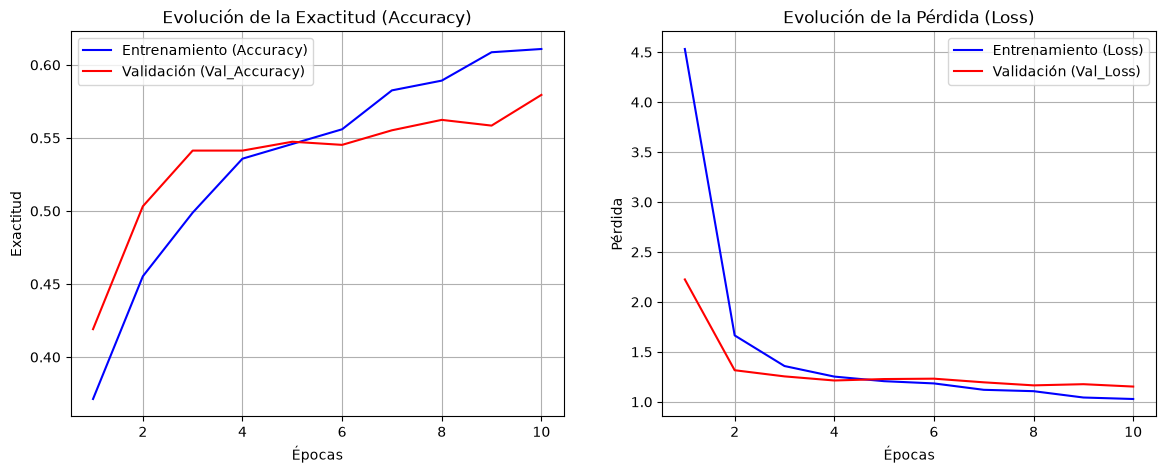

In [11]:
import matplotlib.pyplot as plt

# Extraemos los datos del historial que guardamos al entrenar
acc = historial.history['accuracy']
val_acc = historial.history['val_accuracy']
loss = historial.history['loss']
val_loss = historial.history['val_loss']

epocas = range(1, len(acc) + 1)

# Creamos una figura con dos subgráficos (1 fila, 2 columnas)
plt.figure(figsize=(14, 5))

# --- GRÁFICO 1: ACCURACY (Exactitud) ---
plt.subplot(1, 2, 1)
plt.plot(epocas, acc, 'b-', label='Entrenamiento (Accuracy)')
plt.plot(epocas, val_acc, 'r-', label='Validación (Val_Accuracy)')
plt.title('Evolución de la Exactitud (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Exactitud')
plt.legend()
plt.grid(True)

# --- GRÁFICO 2: LOSS (Pérdida) ---
plt.subplot(1, 2, 2)
plt.plot(epocas, loss, 'b-', label='Entrenamiento (Loss)')
plt.plot(epocas, val_loss, 'r-', label='Validación (Val_Loss)')
plt.title('Evolución de la Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

plt.show()

Se logra visualizar de que el modelo presenta overfiting, esto el modelo deja de aprnder en unmoento, por la epoca tres deja de apredner y deja de ser mas preciso, si no que entra en un tipo bucle. Para prevenir se aplicara algo que se conoce como capa dropout, esta capa apaga neuronas al azar para que el modelo deje de memorizar

In [12]:
import tensorflow as tf

print("--- 1. ARQUITECTURA MEJORADA (CON DROPOUT) ---")
modelo = tf.keras.Sequential([
    # Entrada
    tf.keras.layers.Flatten(input_shape=(150, 150, 3)),
    
    # Primera capa oculta + Dropout
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.3), # Apaga el 30% al azar
    
    # Segunda capa oculta + Dropout
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3), # Apaga el 30% al azar , esto ayuda a que el modelo se esfuerze en aprender
    
    # Salida
    tf.keras.layers.Dense(6, activation='softmax')
])

modelo.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

--- 1. ARQUITECTURA MEJORADA (CON DROPOUT) ---


Se aplicara tambien una vigilancia para parar si es que el modelo empieza a hacer overfitting1

In [13]:
print("\n--- 2. ENTRENAMIENTO PROTEGIDO ---")

# Configuramos la vigilancia (Early Stopping)
parada_temprana = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',         # Vigila el error de validación (la línea roja)
    patience=3,                 # Tolerancia: espera 3 épocas sin mejora
    restore_best_weights=True   # ¡Clave! Devuelve los pesos de la mejor época, no de la última
)

# Ahora podemos pedirle 30 épocas de forma segura
historial = modelo.fit(
    dataset_train_normalizado,
    validation_data=dataset_val_normalizado,
    epochs=30, 
    callbacks=[parada_temprana] # Activamos la vigilancia
)


--- 2. ENTRENAMIENTO PROTEGIDO ---
Epoch 1/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 142s 397ms/step - accuracy: 0.1842 - loss: 3.9338 - val_accuracy: 0.1782 - val_loss: 1.7912
Epoch 2/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 137s 389ms/step - accuracy: 0.1805 - loss: 1.8130 - val_accuracy: 0.1782 - val_loss: 1.7911
Epoch 3/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 136s 386ms/step - accuracy: 0.1792 - loss: 1.7972 - val_accuracy: 0.1782 - val_loss: 1.7912
Epoch 4/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 135s 385ms/step - accuracy: 0.1800 - loss: 1.7966 - val_accuracy: 0.1782 - val_loss: 1.7912
Epoch 5/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 136s 386ms/step - accuracy: 0.1795 - loss: 1.7987 - val_accuracy: 0.1782 - val_loss: 1.7913


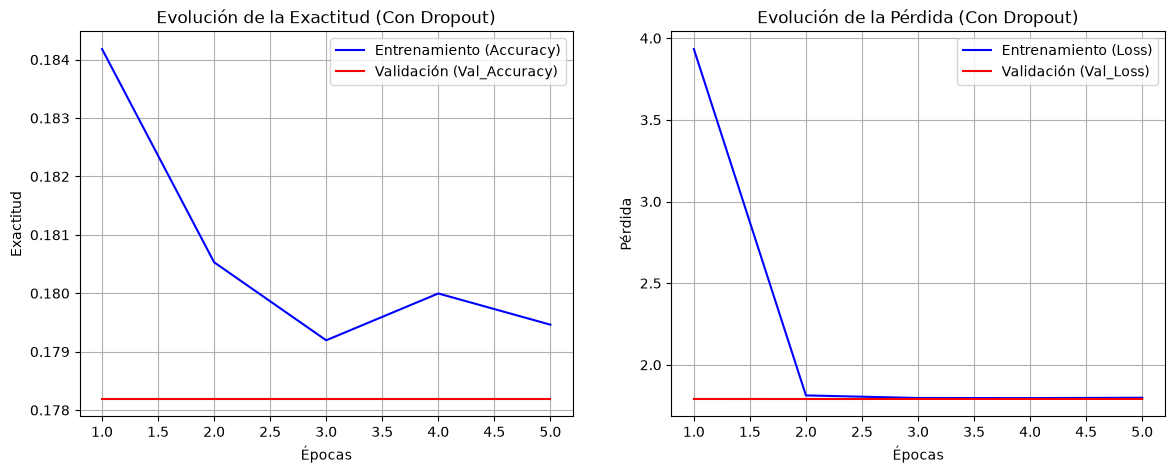

In [14]:
import matplotlib.pyplot as plt

# Extraemos los datos del historial de tu nuevo modelo protegido
acc = historial.history['accuracy']
val_acc = historial.history['val_accuracy']
loss = historial.history['loss']
val_loss = historial.history['val_loss']

epocas = range(1, len(acc) + 1)

# Creamos la figura
plt.figure(figsize=(14, 5))

# --- GRÁFICO 1: ACCURACY ---
plt.subplot(1, 2, 1)
plt.plot(epocas, acc, 'b-', label='Entrenamiento (Accuracy)')
plt.plot(epocas, val_acc, 'r-', label='Validación (Val_Accuracy)')
plt.title('Evolución de la Exactitud (Con Dropout)')
plt.xlabel('Épocas')
plt.ylabel('Exactitud')
plt.legend()
plt.grid(True)

# --- GRÁFICO 2: LOSS ---
plt.subplot(1, 2, 2)
plt.plot(epocas, loss, 'b-', label='Entrenamiento (Loss)')
plt.plot(epocas, val_loss, 'r-', label='Validación (Val_Loss)')
plt.title('Evolución de la Pérdida (Con Dropout)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

plt.show()

Con este grafico podemos ver de que ahora las lineas mas juntas, en otras palabras a desaparecido el overfitting, ademas el modelo al limitarse las neuronas hace que no memorice, de hecho la validacion que no es de entrenamiento termino siendo mejor

## Accurracy , Precision y 	F1


In [15]:
import numpy as np
from sklearn.metrics import classification_report

print("1. Realizando predicciones sobre el dataset de Test (Examen Final)...")
# Extraemos las etiquetas reales y hacemos las predicciones lote por lote
etiquetas_reales = []
predicciones = []

# Recorremos el dataset de prueba que creaste al inicio
for imagenes, etiquetas in dataset_test_normalizado:
    # Guardamos el post-it real
    etiquetas_reales.extend(etiquetas.numpy())
    
    # El modelo da su adivinanza (arroja 6 probabilidades por foto)
    preds_lote = modelo.predict(imagenes, verbose=0)
    
    # Usamos argmax para quedarnos con el número de la clase que tuvo mayor probabilidad
    clases_lote = np.argmax(preds_lote, axis=1)
    predicciones.extend(clases_lote)

# Nombres de las clases (Keras las ordena alfabéticamente por nombre de carpeta)
nombres_clases = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

print("\n--- REPORTE DE CLASIFICACIÓN (Accuracy, Precision, F1) ---")
# Generamos la tabla con todas las métricas
reporte = classification_report(etiquetas_reales, predicciones, target_names=nombres_clases)
print(reporte)

1. Realizando predicciones sobre el dataset de Test (Examen Final)...

--- REPORTE DE CLASIFICACIÓN (Accuracy, Precision, F1) ---
              precision    recall  f1-score   support

   buildings       0.00      0.00      0.00       437
      forest       0.00      0.00      0.00       474
     glacier       0.00      0.00      0.00       553
    mountain       0.18      1.00      0.30       525
         sea       0.00      0.00      0.00       510
      street       1.00      0.00      0.00       501

    accuracy                           0.18      3000
   macro avg       0.20      0.17      0.05      3000
weighted avg       0.20      0.18      0.05      3000



c:\Users\gabod\OneDrive\Escritorio\Proyecto MLP\mi_entorno\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\gabod\OneDrive\Escritorio\Proyecto MLP\mi_entorno\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\gabod\OneDrive\Escritorio\Proyecto MLP\mi_entorno\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

Analizando el repote , podemos ver que el modelo fue muy malo detectando cuales verdaderamente pertenecian a buildings y sea, esto tambien se ve en su f1 score que es la combinacion de la presicion y el recall. Todos los demas obtuvieron muy buen puntaje en los reportes.

## Matriz de confusión

Generando Matriz de Confusión...


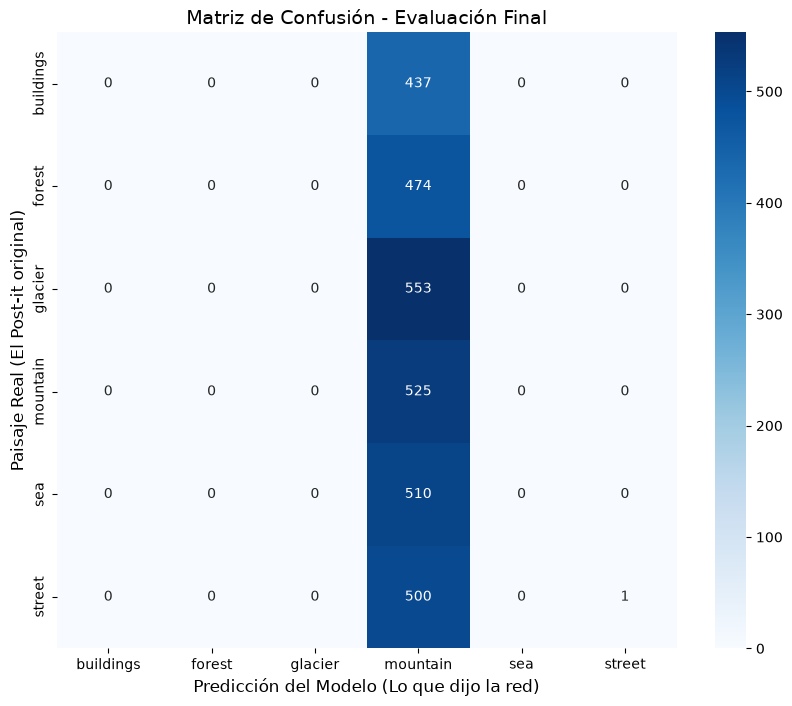

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

print("Generando Matriz de Confusión...")

# Calculamos los valores de la matriz
matriz = confusion_matrix(etiquetas_reales, predicciones)

# Configuramos el tamaño y estilo del gráfico
plt.figure(figsize=(10, 8))

# Creamos un mapa de calor (heatmap)
# annot=True pone los números dentro de los cuadros
# fmt='d' asegura que los números sean enteros (no decimales)
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nombres_clases, 
            yticklabels=nombres_clases)

plt.title('Matriz de Confusión - Evaluación Final', fontsize=14)
plt.xlabel('Predicción del Modelo (Lo que dijo la red)', fontsize=12)
plt.ylabel('Paisaje Real (El Post-it original)', fontsize=12)

plt.show()

Hallazgos interesantes es que el modelo confundio los mucho los glaciares con el oceano, esto talvez por los colores, streets tambien con forest y building, esto problamente debido a la estrucutra de las fomras en las imagenes . Ahora basandonos en las que tuvieron menos confusiones, el modelo tuvo muy buen rendimineto detetando buildings, forest y ocean

## Imagenes correctamente y erroneamente clasificadas.

Buscando ejemplos de aciertos y errores...


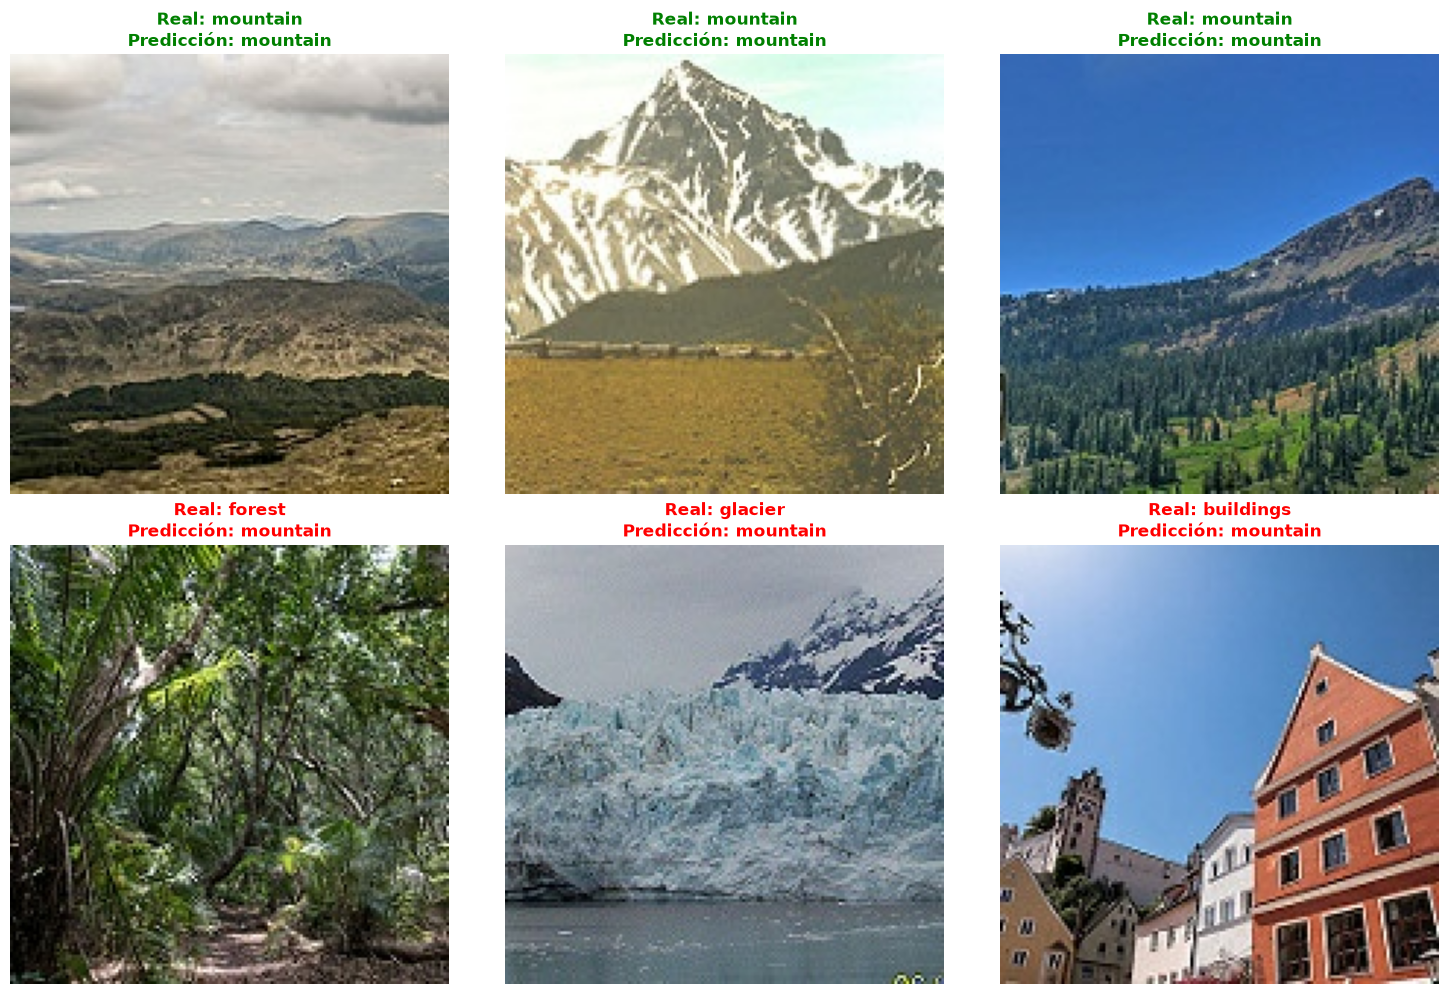

In [17]:
import matplotlib.pyplot as plt
import numpy as np

print("Buscando ejemplos de aciertos y errores...")

# Listas para guardar las imágenes que vamos a mostrar
aciertos = []
errores = []

# Recorremos los lotes de imágenes del Test
for imagenes, etiquetas in dataset_test_normalizado:
    # El modelo hace sus predicciones para este lote
    preds = modelo.predict(imagenes, verbose=0)
    clases_predichas = np.argmax(preds, axis=1)
    clases_reales = etiquetas.numpy()
    
    # Revisamos una por una las imágenes del lote
    for i in range(len(clases_reales)):
        imagen_actual = imagenes[i]
        real = clases_reales[i]
        prediccion = clases_predichas[i]
        
        # Si acertó, la guardamos en la lista de aciertos (máximo 3)
        if real == prediccion and len(aciertos) < 3:
            aciertos.append((imagen_actual, real, prediccion))
            
        # Si se equivocó, la guardamos en la lista de errores (máximo 3)
        elif real != prediccion and len(errores) < 3:
            errores.append((imagen_actual, real, prediccion))
            
    # Si ya encontramos 3 de cada una, detenemos la búsqueda para ahorrar tiempo
    if len(aciertos) == 3 and len(errores) == 3:
        break

# Nombres de las clases para que el texto sea legible
nombres_clases = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

# --- DIBUJAR LOS RESULTADOS ---
# Creamos una figura grande (2 filas, 3 columnas)
plt.figure(figsize=(15, 10))

# 1. Graficar los ACIERTOS (Fila superior)
for i in range(3):
    imagen, real, pred = aciertos[i]
    plt.subplot(2, 3, i + 1) # Posición en la cuadrícula
    plt.imshow(imagen)       # Dibuja la foto
    plt.axis('off')          # Oculta los ejes numéricos
    # Título en verde indicando que acertó
    plt.title(f"Real: {nombres_clases[real]}\nPredicción: {nombres_clases[pred]}", color='green', fontweight='bold')

# 2. Graficar los ERRORES (Fila inferior)
for i in range(3):
    imagen, real, pred = errores[i]
    plt.subplot(2, 3, i + 4) 
    plt.imshow(imagen)       
    plt.axis('off')          
    # Título en rojo indicando el error
    plt.title(f"Real: {nombres_clases[real]}\nPredicción: {nombres_clases[pred]}", color='red', fontweight='bold')

plt.tight_layout()
plt.show()

Como se logra apreciar, al igual que la interpretacion de la matriz de confusion, tiene mucho mucho mejor resultado con mountain

# Problemas presentados y decisiones

El primer problema fue e entrenar los modelos y convertir las imagenes en tensores sin compremeter demasiado la ram del sistema, para esos se decidio hacer las conversione por lotes, respecto a los modelos se cambio el entorno de un entorno mas web como lo es google collab, se traspaso directamente a correr en local.

## Problemas durante el prepocesamiento

Como esta escrito en el parrafo anterior , el princpal problema fue hacer que la convresion de las imagenes a tensores no consumiera mucha ram, la solucion fue hacerlo por lotes.

## Problemas durante el entrenamiento

El unico problema fue el reentrenar el modelo desactivando neuronas para evitar el ovrfitting

# Conclusión

El objetivo se cumplio, el modelo es capaz de identificar iagenes bajo las 6 categorias , los mejores resutlados fueron las categorias donde hay mucos elementos en pantalla o colores remaccados, como lo es la clase forest. Para el futuro se debe considerar le overfitting , la cantiad de epoca  y como no colapsar el sistema. Lo bueno de este modelo es que es facil de implementar, librerias como keras toma pocas funiones, ademas va bien con las predicciones lineales, osea con datos de entrada y salida. Lo que si es un modelo exigente (en lo que respecta la fuerza de computo), esto debido a al flujo de datos entre conexiones neuronales.